In [1]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
framedir='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/sbois_final/inter/inter2020/M15/absolute/m10/116A_05207_252525'
frame=os.path.basename(framedir)
cumfile=os.path.join(framedir,'TS_GEOCml10/cum.h5')


In [3]:
# Load data
with h5.File(cumfile, 'r') as f:
    cum = f['cum'][()]
    imdates = f['imdates'][()].astype(str)
    tide = f['tide'][()]
    iono = f['iono'][()]

# Reference all to first epoch
cum = cum - cum[0]
tide = tide - tide[0]
iono = iono - iono[0]

# # Get daz correction (azimuth ionospheric delay)
# dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
# dazes['epoch'] = pd.to_datetime(dazes['epoch'])
# dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# # Interpolate daz to match imdates
# df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
# df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
# df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
# daz = df_daz['daz'].to_numpy()
# daz = daz - daz[0]  # Align to first epoch

# # Apply all corrections
# cum_abs = cum + daz[:, None, None] - tide - iono

In [4]:
cumaa = xr.load_dataset(cumfile)

In [5]:
cumaa

<xarray.Dataset>
Dimensions:       (phony_dim_0: 468, phony_dim_1: 387, phony_dim_2: 195,
                   phony_dim_3: 194)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/26)
    E.geo         (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    N.geo         (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    U.geo         (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    bperp         (phony_dim_2) float64 -116.0 110.0 -110.0 ... 126.0 -102.0
    coh_avg       (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    corner_lat    float64 40.26
    ...            ...
    vintercept    (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    tide          (phony_dim_2, phony_dim_0, phony_dim_1) float32 nan ... nan
    iono          (phony_dim_2, phony_dim_0, phony_dim_1) float32 nan ... nan
    cum_abs       (phony_dim_2, phony_dim_0, phony_dim_1) float32 nan ... nan
    vel           (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan
    vel_abs       (phony_dim_0, phony_dim_1) float32 nan nan nan ... nan nan nan

In [6]:
cumaa

<xarray.Dataset>
Dimensions:                (phony_dim_0: 463, phony_dim_1: 383,
                            phony_dim_2: 37, phony_dim_3: 36)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/30)
    E.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    N.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    U.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    bperp                  (phony_dim_2) float64 -56.0 -61.0 ... -27.0 -18.0
    coh_avg                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    corner_lat             float64 39.36
    ...                     ...
    cum_abs                (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide         (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide_noiono  (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    vel_abs                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide         (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide_noiono  (phony_dim_0, phony_dim_1) float32 nan nan ... nan

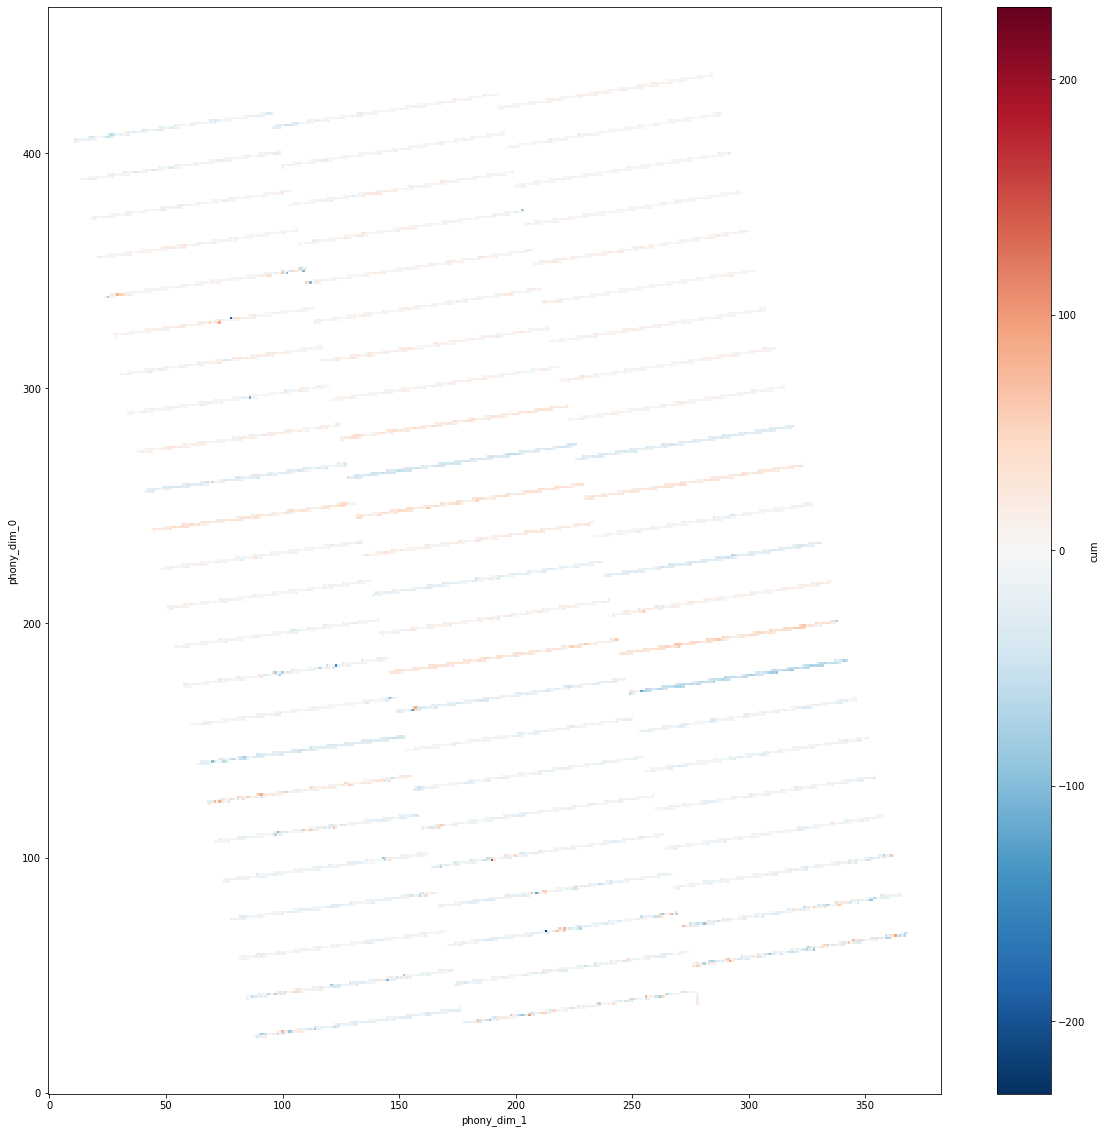

In [6]:
cumaa.cum[1].plot(figsize=(20,20))

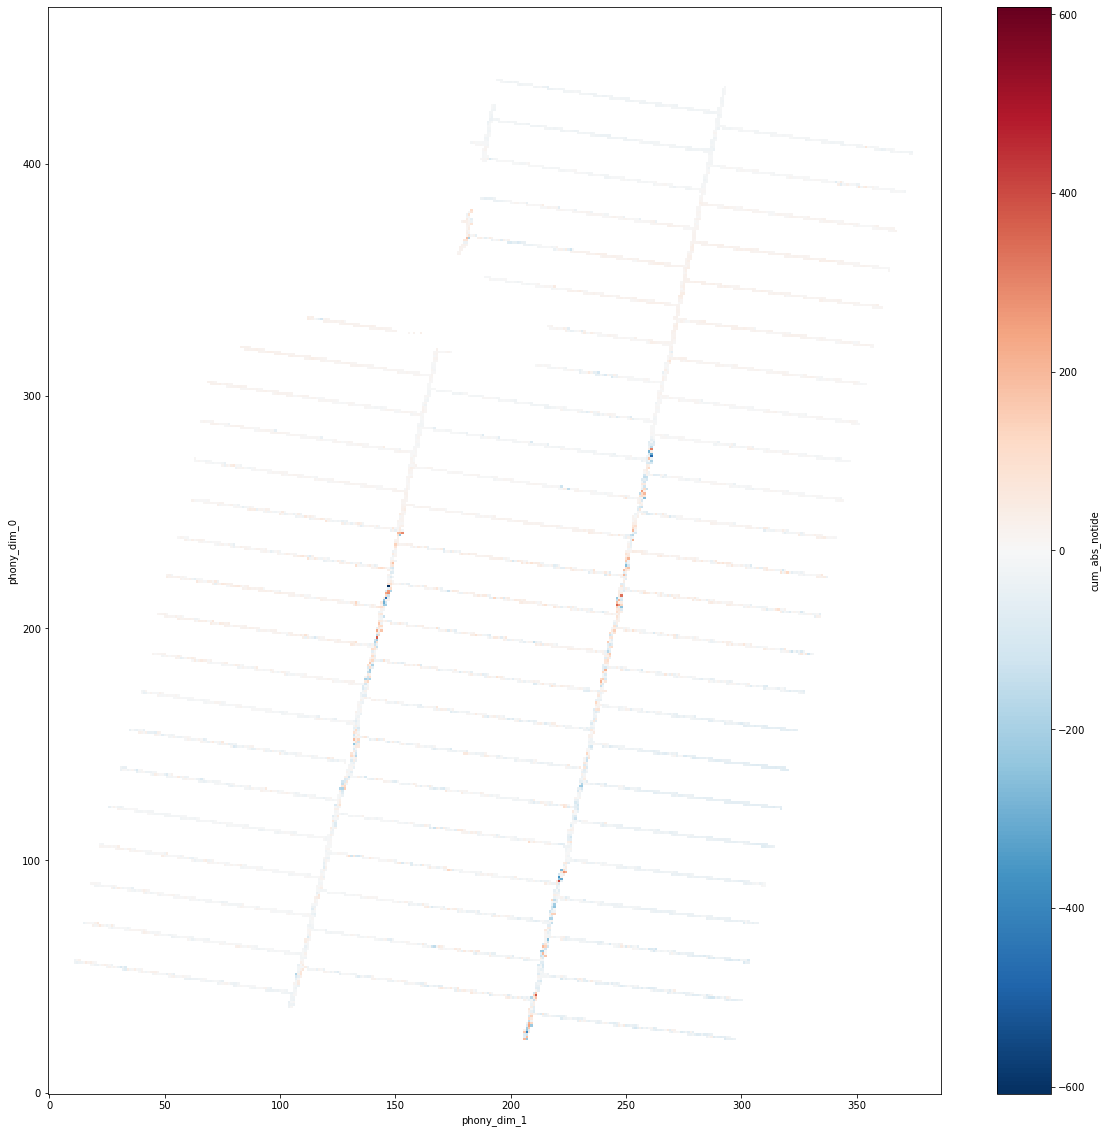

In [8]:
cumaa.cum_abs_notide[1].plot(figsize=(20,20))

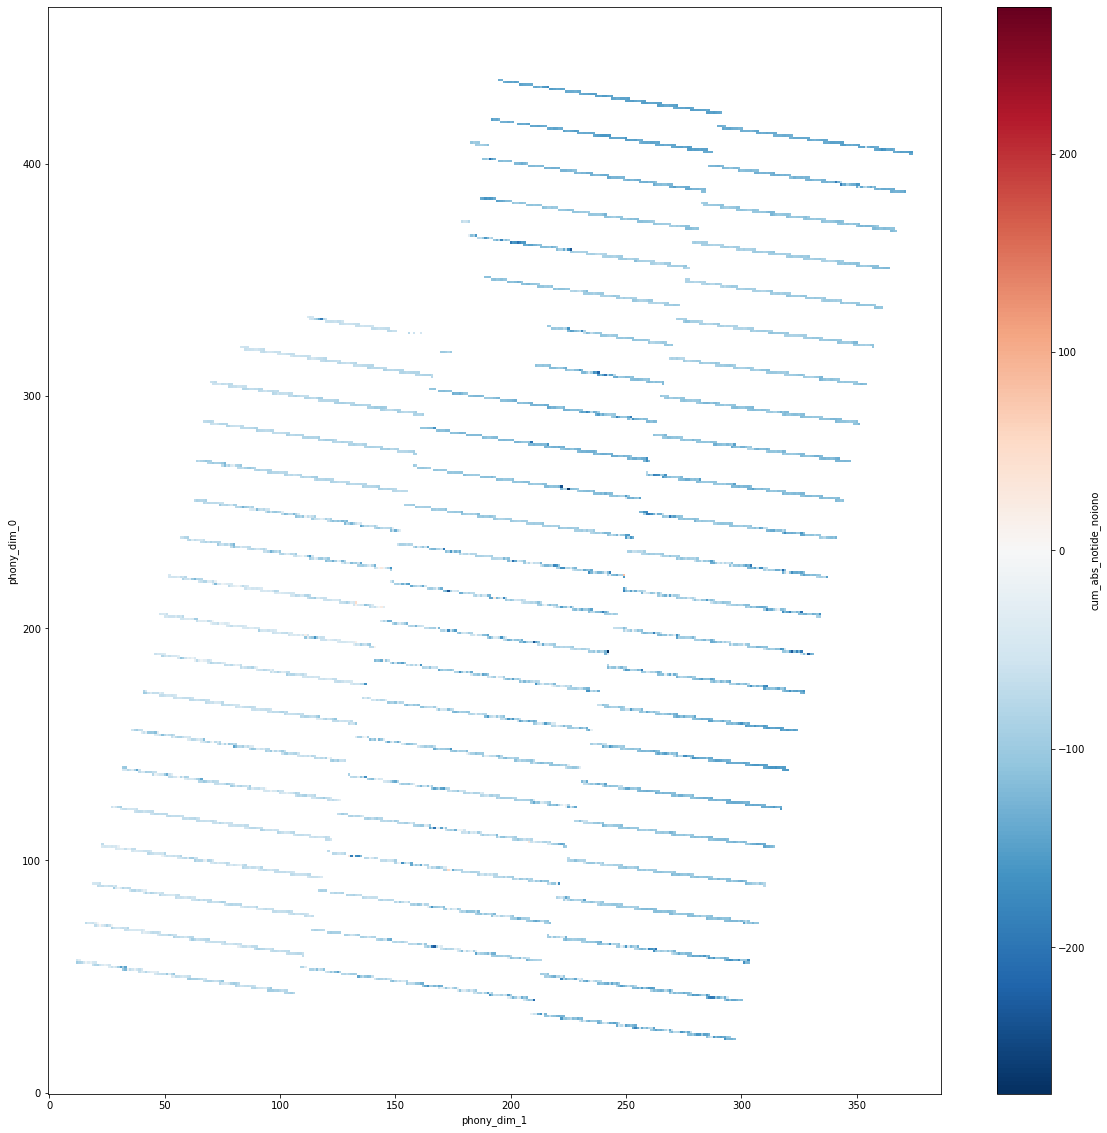

In [9]:
cumaa.cum_abs_notide_noiono[1].plot(figsize=(20,20))

In [17]:
trial_xdataset=cumaa.iono[3]

In [18]:
trial_xdataset

<xarray.DataArray 'iono' (phony_dim_0: 468, phony_dim_1: 387)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Dimensions without coordinates: phony_dim_0, phony_dim_1

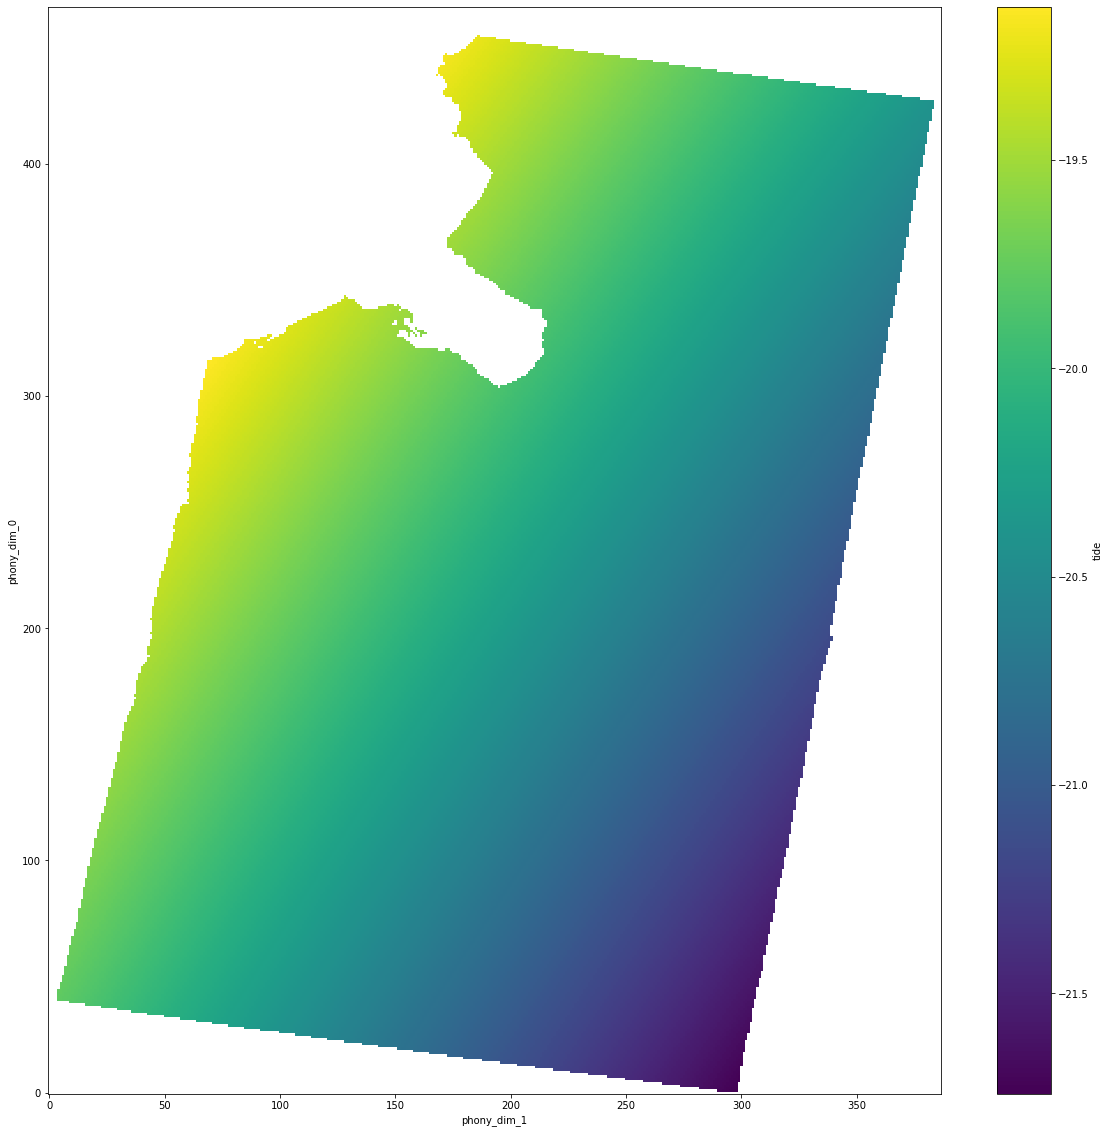

In [15]:
cumaa.tide[3].plot(figsize=(20,20))

In [19]:
cumaa

<xarray.Dataset>
Dimensions:                (phony_dim_0: 468, phony_dim_1: 387,
                            phony_dim_2: 26, phony_dim_3: 25)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/27)
    E.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    N.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    U.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    bperp                  (phony_dim_2) float64 -96.0 94.0 -32.0 ... -28.0 9.0
    coh_avg                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    corner_lat             float64 39.97
    ...                     ...
    vintercept             (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    tide                   (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    iono                   (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs                (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide         (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide_noiono  (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...

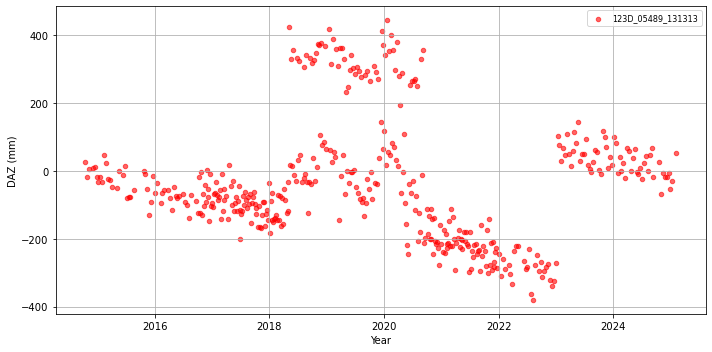

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
frame='123D_05489_131313'
# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# Plotting daz and save
plt.figure(figsize=(10, 5))
plt.scatter(dazes['epoch'], dazes['daz'], color='red', alpha=0.6, s=20, label=frame)
plt.xlabel('Year')             # ✅ FIXED
plt.ylabel('DAZ (mm)')         # ✅ FIXED
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
# plt.savefig(f"{frame}_daz_plot.png", dpi=150)  # Optional: save the plot
plt.show()


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
frame='123D_05489_131313'
# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]

# dazes['epoch'] = pd.to_datetime(dazes['epoch'])
# dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# # Plotting daz and save
# plt.figure(figsize=(10, 5))
# plt.scatter(dazes['epoch'], dazes['daz'], color='red', alpha=0.6, s=20, label=frame)
# plt.xlabel('Year')             # ✅ FIXED
# plt.ylabel('DAZ (mm)')         # ✅ FIXED
# plt.legend(fontsize=8)
# plt.grid(True)
# plt.tight_layout()
# # plt.savefig(f"{frame}_daz_plot.png", dpi=150)  # Optional: save the plot
# plt.show()


In [9]:
help(dl.get_daz_frame)

Help on function get_daz_frame in module daz_lib_licsar:

get_daz_frame(frame, fulloutput=True, include_corrections=False)
    Function to extract all frame daz values from the LiCSInfo database.
    
    Args:
        frame (str)                 LiCSAR frame ID
        fulloutput (bool)           if True, will return all information from the database, otherwise only daz values [mm]
        include_corrections (bool)  if True, will perform also SET and iono corrections and add to the table (or daz if False fulloutput)



In [17]:
a=dl.get_daz_frame(frame, fulloutput=True, include_corrections=True)

JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR GIM data
JPL-HR G

earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge used instead.earthtide [WARNING]: time crossed leap seconds table boundaries. Boundary edge u

<AxesSubplot:>

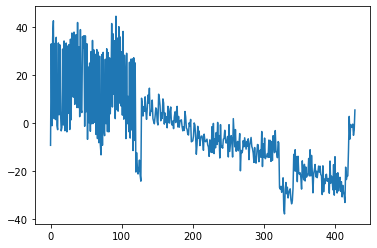

In [24]:
(a.daz*1400).plot()

In [ ]:
a.daz.plot()

In [25]:
dazes=a.copy()

In [28]:
dazes

,polyid,epoch,rslc3,orbfile,daz,cc_azi,cc_range,daz_iono,daz_SET
0,4290,2020-05-15,2020-05-09,,-0.006700,0.00000,0.00000,-0.001212,0.002347
1,4290,2020-08-25,2020-09-06,S1B_OPER_AUX_POEORB_OPOD_20210317T081141_V2020...,0.023505,0.00000,0.00000,-0.000254,0.002234
2,4290,2020-08-31,2020-08-25,S1A_OPER_AUX_POEORB_OPOD_20210317T113721_V2020...,-0.000863,0.00000,0.00000,0.000222,-0.000837
3,4290,2020-09-06,2016-09-09,S1B_OPER_AUX_POEORB_OPOD_20210317T113645_V2020...,0.025392,0.00000,0.00000,-0.000401,0.001268
4,4290,2018-05-08,2018-07-25,fixed_as_in_GRL,0.030380,-0.03737,-0.03626,-0.000607,0.002493
...,...,...,...,...,...,...,...,...,...
424,4290,2024-12-08,2024-10-09,S1A_OPER_AUX_POEORB_OPOD_20241228T070603_V2024...,-0.001292,-0.06099,-0.05866,0.000313,0.002695
425,4290,2024-12-20,2024-10-09,S1A_OPER_AUX_POEORB_OPOD_20250109T070620_V2024...,-0.000390,-0.05607,-0.03870,0.000442,0.001702
426,4290,2025-01-01,2024-10-09,S1A_OPER_AUX_POEORB_OPOD_20250121T070630_V2024...,-0.003717,-0.08521,0.00678,-0.000134,-0.000325
427,4290,2025-01-13,2024-10-09,S1A_OPER_AUX_POEORB_OPOD_20250202T070628_V2025...,-0.002201,-0.06706,0.05134,0.001930,-0.000514


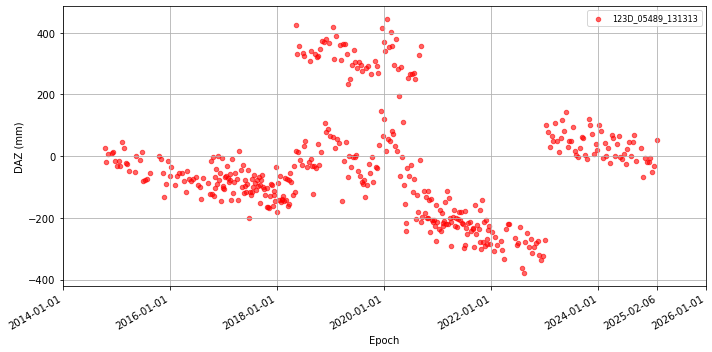

In [27]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], dazes['daz']*14000, color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

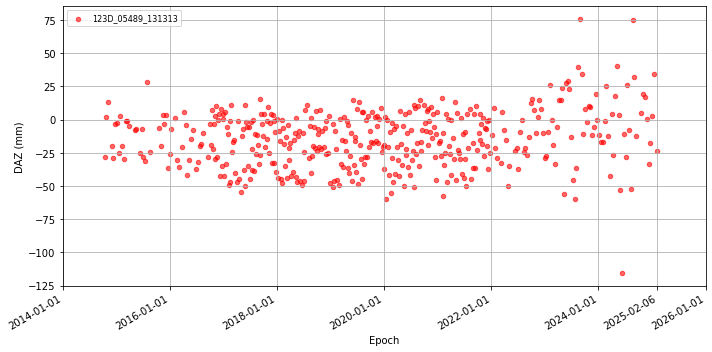

In [33]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], (dazes['daz_iono']-dazes['daz_SET'])*14000, color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

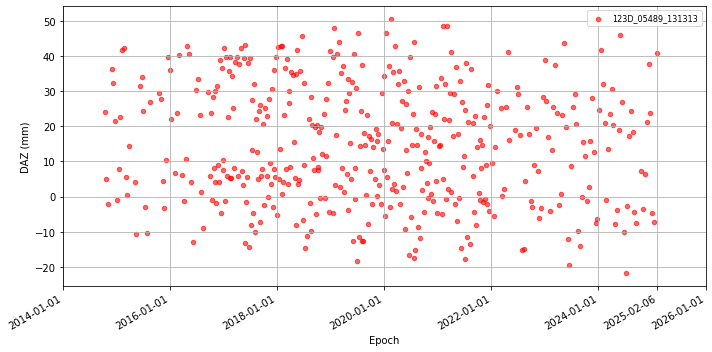

In [32]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], dazes['daz_SET']*14000, color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

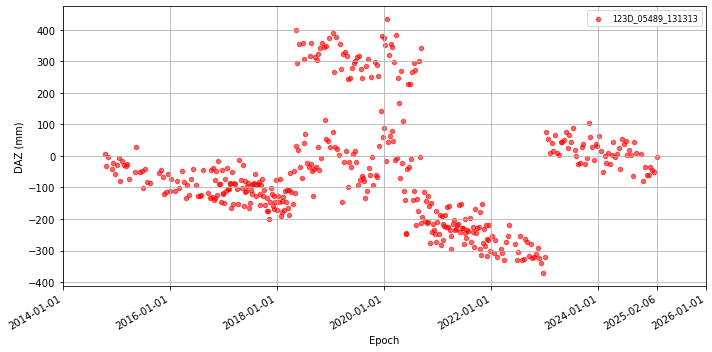

In [30]:
import matplotlib.dates as mdates
# Plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], (dazes['daz']-dazes['daz_iono']-dazes['daz_SET'])*14000, color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
# fig.savefig(f"{frame}_daz_plot.png", dpi=150)
plt.show()

In [14]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming you have a custom module 'dl' that provides your data
# import daz_lib_licsar as dl

# # Load frames_TR from file
# homedir = '/home/users/mnergiz'
# frames_file = os.path.join(homedir, 'frames_TR')

# frames_TR = []
# with open(frames_file, 'r') as f:
#     for line in f:
#         frames_TR.append(line.strip())

# # Prepare subplots
# n = len(frames_TR)
# ncols = 5  # Number of plots per row
# nrows = (n + ncols - 1) // ncols  # Auto calculate rows
# fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=False)
# axs = axs.flatten()

# # Loop through each frame and plot
# for i, frame in enumerate(frames_TR):
#     try:
#         # Load data
#         df = dl.get_daz_frame(frame)[['epoch', 'daz']]
#         df['epoch'] = pd.to_datetime(df['epoch'])
#         df['daz'] = df['daz'] * 14000  # Convert to mm (scale for azimuth geometry)
#         df['epoch'] = pd.to_datetime(df['epoch'], format='%Y%m%d')
#         df = df.sort_values(by='epoch')

#         # Plot
#         axs[i].scatter(df['epoch'], df['daz'], color='red', alpha=0.6, s=10, label=frame)
#         axs[i].set_title(frame, fontsize=10)
#         axs[i].set_xlabel('Year')
#         axs[i].set_ylabel('DAZ × 14000 (mm)')
#         axs[i].legend(fontsize=8)
#         axs[i].grid(True)
#         xticks = pd.date_range(start=df['epoch'].min(), end=df['epoch'].max(), freq='YS')
#         axs[i].set_xticks(xticks)
#         axs[i].set_xticklabels(xticks.year, rotation=45)
#     except Exception as e:
#         print(f"Failed to process {frame}: {e}")
#         axs[i].set_visible(False)

# # Hide any unused subplots
# for j in range(i + 1, len(axs)):
#     axs[j].set_visible(False)

# plt.tight_layout()
# plt.show()


In [43]:
frame

'050D_05443_121313'

Reading cum.h5 from: /work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic/inter/sbois_mw6/050D_05443_121313/TS_GEOCml10/cum.h5


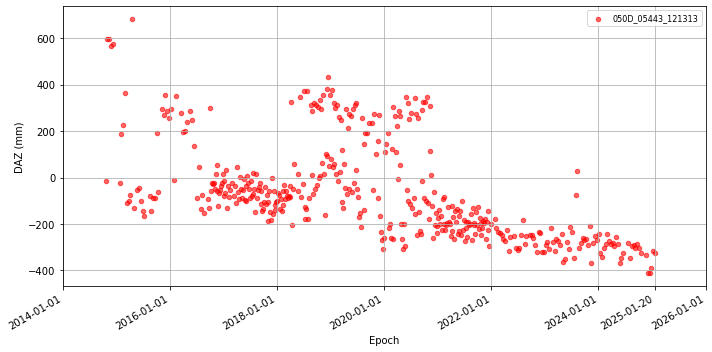

In [61]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

frame='050D_05443_121313'
tsadir=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic/inter/sbois_mw6/{frame}/TS_GEOCml10'
#%%Read data information
cumfile=os.path.join(tsadir,'cum.h5')
if not os.path.exists(cumfile):
    print('Error reading specified input file, please fix')
    
#%%Read cum.h5, add daz values and remove tide and iono corrections
print(f"Reading cum.h5 from: {cumfile}")
# Load data
with h5.File(cumfile, 'r') as f:
    cum = f['cum'][()]
    imdates = f['imdates'][()].astype(str)
    
    # check if they exist.
    tide_exists = 'tide' in f
    iono_exists = 'iono' in f
    
    tide = f['tide'][()] if tide_exists else np.zeros_like(cum)
    iono = f['iono'][()] if iono_exists else np.zeros_like(cum)
    

# Reference all to first epoch
cum = cum - cum[0]
if tide_exists:
    tide = tide - tide[0]
if iono_exists:
    iono = iono - iono[0]


# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)
##plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(dazes['epoch'], dazes['daz'], color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = dazes['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
plt.savefig(os.path.join(tsadir, f"{frame}_daz_plot.png"), dpi=150)

# Interpolate daz to match imdates
df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
#### checking the sizes is not fit.
df_daz = df_daz.drop_duplicates(subset='epoch')  # Just in case
if len(df_daz) != len(imdates):
    raise ValueError(f"Mismatch in time steps after merge: imdates={len(imdates)}, df_daz={len(df_daz)}")
#####

df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
daz = df_daz['daz'].to_numpy()
daz = daz - daz[0]  # Align to first epoch

###daz modelling?


# # Apply all corrections ##TODO save only final result when you satify with the results
# cum_abs = cum + daz[:, None, None] # Add daz correction
# apply tide and iono corrections if they exists

# if tide_exists:
#     cum_abs_notide = cum_abs - tide
# else:
#     cum_abs_notide = cum_abs.copy()

# if iono_exists:
#     cum_abs_notide_noiono = cum_abs_notide - iono   #if the no set is hthe applied notide_noiono represents the noiono
# else:
#     cum_abs_notide_noiono = cum_abs_notide.copy()

# # Save corrected datasets
# print(f"Writing corrected cumulative datasets to {cumfile} ...")
# with h5.File(cumfile, 'r+') as f:
#     for name, data in {
#         'cum_abs': cum_abs,
#         'cum_abs_notide': cum_abs_notide,
#         'cum_abs_notide_noiono': cum_abs_notide_noiono
#     }.items():
#         if name in f:
#             del f[name]
#         f.create_dataset(name, data=data.astype('float32'), compression='gzip')
    

# #%% Finish
# elapsed_time = time.time()-start
# hour = int(elapsed_time/3600)
# minite = int(np.mod((elapsed_time/60),60))
# sec = int(np.mod(elapsed_time,60))
# print("\nElapsed time: {0:02}h {1:02}m {2:02}s".format(hour,minite,sec))

# print('\n{} Successfully finished!!\n'.format(os.path.basename(argv[0])))
# # print('Output directory: {}\n'.format(os.path.relpath(tsadir)))



In [62]:
df_daz

,epoch,daz
0,2016-01-08,292.906600
1,2016-02-01,-10.925166
2,2016-02-13,348.982200
3,2016-03-20,276.641400
4,2016-04-01,194.373200
...,...,...
335,2022-12-14,-319.282600
336,2022-12-26,-320.307400
337,2023-01-07,-290.731000
338,2023-01-19,-279.767600


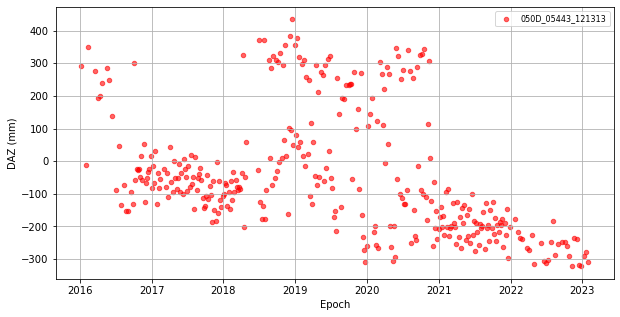

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_daz['epoch'], df_daz['daz'], color='red', alpha=0.6, s=20, label=frame)

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

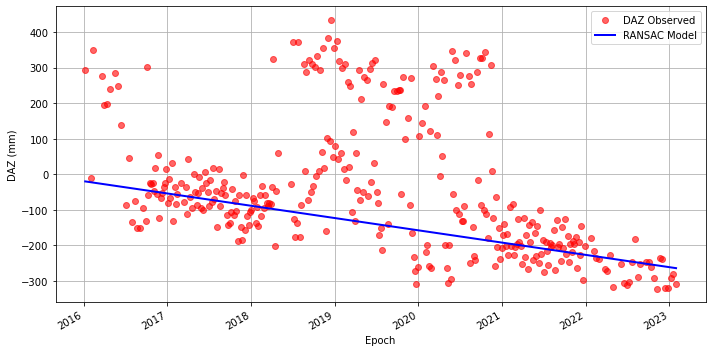

In [67]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
# Convert epoch to numeric time in days
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)  # model prediction for all dates

# Plot DAZ and DAZ model
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_daz['epoch'], df_daz['daz'], 'o', color='red', alpha=0.6, label='DAZ Observed')
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], '-', color='blue', lw=2, label='RANSAC Model')

ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [68]:
df_daz

,epoch,daz,days,daz_model
0,2016-01-08,292.906600,0,-20.132536
1,2016-02-01,-10.925166,24,-22.403829
2,2016-02-13,348.982200,36,-23.539475
3,2016-03-20,276.641400,72,-26.946414
4,2016-04-01,194.373200,84,-28.082061
...,...,...,...,...
335,2022-12-14,-319.282600,2532,-259.753924
336,2022-12-26,-320.307400,2544,-260.889571
337,2023-01-07,-290.731000,2556,-262.025217
338,2023-01-19,-279.767600,2568,-263.160863


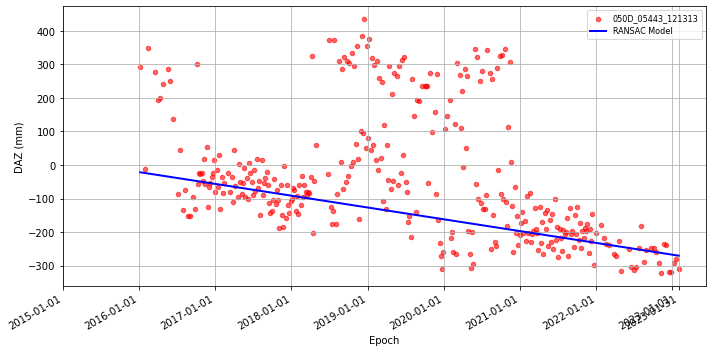

In [77]:
# Get daz correction (azimuth ionospheric delay)
dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
dazes['epoch'] = pd.to_datetime(dazes['epoch'])
dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# Interpolate daz to match imdates
df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
#### checking the sizes is not fit.
df_daz = df_daz.drop_duplicates(subset='epoch')  # Just in case
if len(df_daz) != len(imdates):
    raise ValueError(f"Mismatch in time steps after merge: imdates={len(imdates)}, df_daz={len(df_daz)}")
#####

##Modelling the daz values with RANSAC
# Convert epoch to numeric time in days
t0 = df_daz['epoch'].min()
df_daz['days'] = (df_daz['epoch'] - t0).dt.days

X = df_daz['days'].values.reshape(-1, 1)
y = df_daz['daz'].values
mask = ~np.isnan(y)

# Fit RANSAC
if np.sum(mask) < 2:
    vel_ransac = np.nan
    intercept_ransac = np.nan
    df_daz['daz_model'] = np.nan
else:
    reg = RANSACRegressor(base_estimator=LinearRegression()).fit(X[mask], y[mask])
    vel_ransac = reg.estimator_.coef_[0]
    intercept_ransac = reg.estimator_.intercept_
    df_daz['daz_model'] = reg.predict(X)  # model prediction for all dates

df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
daz = df_daz['daz'].to_numpy()
daz = daz - daz[0]  # Align to first epoch

##plotting daz and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_daz['epoch'], df_daz['daz'], color='red', alpha=0.6, s=20, label=frame)
if 'daz_model' in df_daz:
    ax.plot(df_daz['epoch'], df_daz['daz_model'], '-', color='blue', lw=2, label='RANSAC Model')

# Set labels and grid
ax.set_xlabel('Epoch')
ax.set_ylabel('DAZ (mm)')
ax.legend(fontsize=8)
ax.grid(True)

# Force last date into x-ticks
last_date = df_daz['epoch'].max()
xticks = list(ax.get_xticks())  # Default ticks
xticks.append(mdates.date2num(last_date))  # Add last date in float format
ax.set_xticks(sorted(set(xticks)))  # Ensure unique & sorted

# Use date formatter
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()  # Auto-format angle of date labels

# Save and show
fig.tight_layout()
plt.savefig(os.path.join(tsadir, f"{frame}_daz_plot.png"), dpi=150)

In [78]:
df_daz

,epoch,daz,days,daz_model
0,2016-01-08,292.906600,0,-21.764217
1,2016-02-01,-10.925166,24,-24.076099
2,2016-02-13,348.982200,36,-25.232040
3,2016-03-20,276.641400,72,-28.699863
4,2016-04-01,194.373200,84,-29.855804
...,...,...,...,...
335,2022-12-14,-319.282600,2532,-265.667756
336,2022-12-26,-320.307400,2544,-266.823697
337,2023-01-07,-290.731000,2556,-267.979638
338,2023-01-19,-279.767600,2568,-269.135579
